In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
methods = ['Uncalib', 'Platt', 'HB', 'LINR', 'LOGR', 'IGHB', 'IGLB']

results_qwen = {
     'Complexity':       [-0.243406, 0.160069, 0.159981, 0.193489, -0.159551, -0.183953,  0.182182 ],
     'Length':      [-0.243406, 0.160069, 0.159981, 0.171875,  -0.222495, -0.122333, 0.155102 ],
     'Language':        [-0.243406, 0.160069, 0.159981, 0.249676 , -0.0897221, -0.243406,  0.285937],
     'Length & Comp.':[-0.243406, 0.160069, 0.159981, 0.196731, -0.166435, -0.122333, 0.195569 ],
     'Lang. & Comp.':   [-0.243406, 0.160069, 0.159981, 0.290389, 0.00469423, -0.183953, 0.241252  ],
     'Length & Lang.': [-0.243406, 0.160069, 0.159981, 0.276747, -0.0021903, -0.122333, 0.260551],
     'Length, Lang. & Comp.':         [-0.243406, 0.160069, 0.159981, 0.297414, 0.0381334, -0.122333, 0.317381]
}

results_r1 = {
    'Complexity':        [-0.669695, 0.0929692,  0.112199, 0.105417 , -0.294587, -0.447137, 0.140853 ],
     'Length':      [-0.669695, 0.0929692, 0.112199, 0.272984, -0.103641, -0.0394072, 0.281807],
     'Language' :       [-0.669695, 0.0929692,  0.112199,  0.320375, -0.020778, -0.669695, 0.39212 ],
     'Length & Comp.':[-0.669695, 0.0929692,  0.112199, 0.279604, -0.0700155, -0.0394072, 0.303114 ],
     'Lang. & Comp.' : [-0.669695, 0.0929692,  0.112199,  0.333483,  0.0128477, -0.447137, 0.418732],
     'Length & Lang.': [-0.669695, 0.0929692,  0.112199,  0.442316,  0.302268, -0.0394072, 0.509892 ],
     'Length, Lang. & Comp.' :        [-0.669695, 0.0929692,  0.112199, 0.446633, 0.311876,  -0.0394072, 0.479345 ]
}

results_gpt_oss = {
     'Complexity':       [ -0.228201, 0.0973732, 0.0936375, 0.155204, -0.320284, -0.228201,  0.156447] ,
     'Length':      [ -0.228201, 0.0973732, 0.0936375, 0.170652, -0.281756 , -0.0381656,  0.170575] ,
     'Language':        [ -0.228201, 0.0973732, 0.0936375, 0.164383, -0.323103,  -0.228201, 0.177932] ,
     'Length & Comp.':[ -0.228201, 0.0973732, 0.0936375, 0.196277 , -0.240409,  -0.0381656, 0.194855],
     'Lang. & Comp.':  [ -0.228201, 0.0973732, 0.0936375, 0.219642, -0.153017, -0.228201, 0.230581],
     'Length & Lang.': [ -0.228201, 0.0973732, 0.0936375, 0.226258,  -0.148318,  -0.0381656,  0.236801],
     'Length, Lang. & Comp.':         [ -0.228201, 0.0973732, 0.0936375, 0.25056, -0.091936 , -0.0381656, 0.249366 ]
}

results_mean = {key:[np.mean((a,b,c)) for a,b,c in zip(results_qwen[key], results_r1[key], results_gpt_oss[key])] for key in results_qwen}

results_std = {key:[np.std((a,b,c)) for a,b,c in zip(results_qwen[key], results_r1[key], results_gpt_oss[key])] for key in results_qwen}

row_data = {'Approach':[],
           'Groups':[],
           'BSS':[]}

for groups, vals in results_mean.items():
    for method, val in zip(methods, vals):
        row_data['Approach'].append(method)
        row_data['Groups'].append(groups)
        row_data['BSS'].append(val)
        
df_mean = pd.DataFrame.from_dict(row_data)

categories = {
    "Single Category": ['Complexity',  'Length', "Language"],
    "Pair of Categories": ['Length & Comp.', 'Lang. & Comp.', 'Length & Lang.'],
    "All":['Length, Lang. & Comp.']
}


df_mean.loc[:, 'category'] = df_mean.Groups.apply(lambda x: [k for k,v in categories.items() if x in v][0])



df_selected = df_mean[df_mean['Approach'].isin(['Platt', 'HB', 'LINR', 'IGLB'])]

df_selected


,Approach,Groups,BSS,category
1,Platt,Complexity,0.116804,Single Category
2,HB,Complexity,0.121939,Single Category
3,LINR,Complexity,0.151370,Single Category
6,IGLB,Complexity,0.159827,Single Category
8,Platt,Length,0.116804,Single Category
9,HB,Length,0.121939,Single Category
10,LINR,Length,0.205170,Single Category
13,IGLB,Length,0.202495,Single Category
15,Platt,Language,0.116804,Single Category
16,HB,Language,0.121939,Single Category


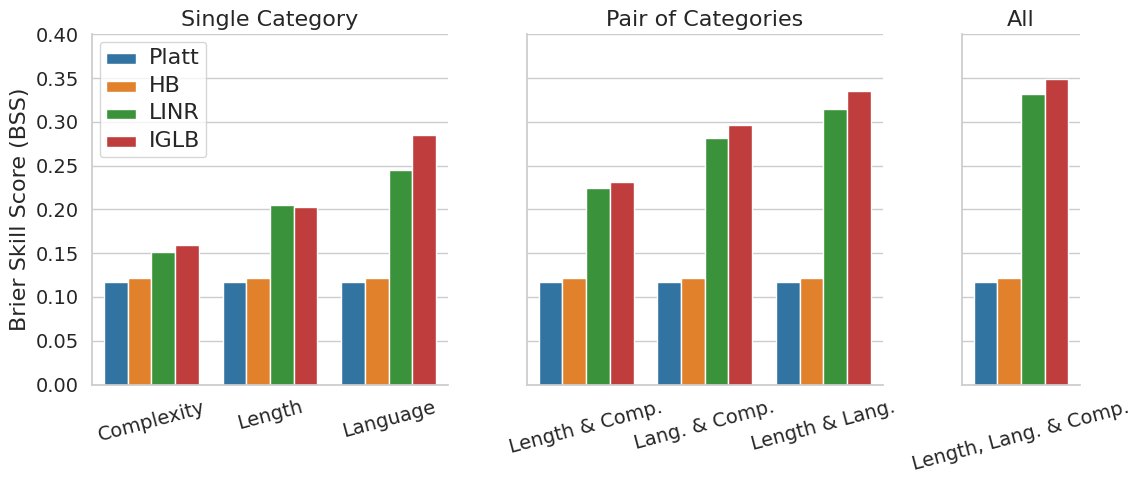

In [ ]:

sns.set_theme(style='whitegrid')

plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)


axis_grid = sns.catplot(data=df_selected, 
                        kind="bar", 
                        x="Groups", 
                        y="BSS", 
                        hue="Approach", 
                        col="category", 
                        sharex=False, 
                        sharey=True, 
                        legend=True, 
                        legend_out=False,
                        height=5, 
                        aspect=0.77, 
                        palette=sns.color_palette("tab10", 4),
                        facet_kws={'gridspec_kws': {'width_ratios': [3,3,1]}})
axis_grid.set(ylim=(0, 0.4))

#plt.legend(title='Approach', loc='upper right', fontsize=12)

axis_grid.set_axis_labels("", "Brier Skill Score (BSS)", fontsize=16)
axis_grid.set_titles("{col_name}", size=16)
for t in axis_grid._legend.texts:
    t.set_fontsize(16)
axis_grid._legend.set_title("")
axis_grid.set_xticklabels(rotation=15)

plt.tight_layout()
plt.savefig("ablation_bars.pdf")

plt.show()